# [FD003] Análisis Exploratorio de Datos (EDA) Orientado a Diagnóstico y Pronóstico de RUL

## Objetivo General
Ejecutar un Análisis Exploratorio de Datos (EDA) formal, cuantitativo y reproducible sobre el subconjunto **FD003** del benchmark C-MAPSS de la NASA. El propósito de este estudio es caracterizar el comportamiento del sistema ante un escenario de **régimen operativo único (nivel del mar)** pero con **dos modos de falla latentes no etiquetados** (degradación en el Compresor de Alta Presión - HPC y degradación en el Ventilador - Fan).

A través de este notebook se busca:
1. Validar la estructura e integridad física del dataset frente al subconjunto canónico FD001.
2. Demostrar cuantitativamente la invariancia de sensores en condición de nivel del mar para justificar la reducción del espacio de características.
3. Extraer la firma de degradación acelerada en ventanas terminales de operación ($N = 30$ ciclos previos a la falla).
4. Reducir la dimensionalidad mediante **PCA en 3D** y aislar las dos poblaciones de falla mediante clustering no supervisado ($K = 2$) evaluado con Silhouette Score.
5. Interpretar la divergencia termodinámica entre ambos modos de falla sobre sensores clave del núcleo y del flujo secundario.
6. Establecer el subconjunto de sensores resultante para el archivo de configuración `configs/config_FD003.yaml`.

### Referencias Canónicas
* **Saxena, A., Goebel, K., Simon, D., & Eklund, N. (2008).** *Damage propagation modeling for aircraft engine run-to-failure simulation*. PHM '08, IEEE.
* **Heimes, F. O. (2008).** *Recurrent neural networks for remaining useful life estimation*. PHM '08, IEEE.
* **Zheng, S., Ristovski, K., Farahat, A., & Gupta, C. (2017).** *Long Short-Term Memory Network for Remaining Useful Life Estimation*. IEEE Big Data.
* **Li, X., Ding, Q., & Sun, J. (2018).** *Remaining useful life estimation in prognostics using deep convolution neural networks*. Reliability Engineering & System Safety.
* **Deepika, P., et al. (2025).** *Multi-Stage CNN-LSTM for Remaining Useful Life Estimation in Complex Multi-Fault Regimes*. Sensors.


In [1]:
import os
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.stats import spearmanr, linregress, iqr

# Configuración estilo publicación (IEEE/Nature)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})
sns.set_palette('colorblind')

# Rutas del proyecto
PROJECT_ROOT = Path(os.path.abspath('..')) if os.path.exists('../datos') else Path(os.path.abspath('.'))
DATA_DIR = PROJECT_ROOT / 'datos'
FIGURES_DIR = PROJECT_ROOT / 'notebooks' / 'figures' / 'FD003'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def guardar_fig(nombre, fig=None):
    """Guarda la figura en notebooks/figures/FD003 como PNG (300 dpi) y PDF."""
    if fig is None:
        fig = plt.gcf()
    png = FIGURES_DIR / f'{nombre}.png'
    pdf = FIGURES_DIR / f'{nombre}.pdf'
    fig.savefig(png, dpi=300, bbox_inches='tight')
    fig.savefig(pdf, dpi=300, bbox_inches='tight')
    print(f'  Guardado: {png.relative_to(PROJECT_ROOT)} (+ .pdf)')
    return png

# Nombres de columnas oficiales de C-MAPSS
INDEX_COLS = ['unit_number', 'time_cycles']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS = [f'sensor_{i}' for i in range(1, 22)]
COLUMN_NAMES = INDEX_COLS + SETTING_COLS + SENSOR_COLS

print('Configuración cargada.')
print(f'Ruta del proyecto: {PROJECT_ROOT}')
print(f'Ruta de los datos: {DATA_DIR}')
print(f'Ruta de figuras:   {FIGURES_DIR}')
print(f'Total columnas:    {len(COLUMN_NAMES)}')


Configuración cargada.
Ruta del proyecto: /home/jair/Proyectos/RUL-CMAPSS
Ruta de los datos: /home/jair/Proyectos/RUL-CMAPSS/datos
Ruta de figuras:   /home/jair/Proyectos/RUL-CMAPSS/notebooks/figures/FD003
Total columnas:    26


---

## Sección 1: Inspección de Estructura e Integridad del Dataset (FD003 vs FD001)

### Fundamentación Metodológica
El subconjunto **FD003** comparte con FD001 la condición operativa a nivel del mar (`setting_1` $\approx 0$, `setting_2` $\approx 0$, `setting_3` $= 100.0$), pero se diferencia en que los 100 motores de entrenamiento sufren degradación en dos subsistemas distintos (HPC o Fan). Cada trayectoria representa una serie de tiempo multivariante *run-to-failure* completa, donde el motor inicia en estado saludable con variabilidad estocástica de fabricación y desgaste inicial, y finaliza cuando los límites de seguridad operativa son violados ($RUL = 0$).

En esta sección se verifica:
1. La ausencia de datos faltantes (NaN), valores infinitos o inconsistencias estructurales.
2. La distribución de longevidad de las 100 unidades de entrenamiento.
3. Una comparación estadística explícita entre la vida útil de los motores en FD003 y FD001 para cuantificar el impacto de la multiplicidad de fallas sobre la duración del componente.


In [2]:
# Sección 1: Inspección de Estructura e Integridad del Dataset
# Propósito: Cargar train_FD003.txt, comprobar integridad física y comparar longevidad con FD001.
# Fundamento: Verificar ausencia de anomalías de adquisición y caracterizar la vida útil estocástica.
# Referencia: Saxena et al. (2008).

# 1. Carga de datos
train_file = DATA_DIR / 'train_FD003.txt'
df_train = pd.read_csv(train_file, sep=r'\s+', header=None, names=COLUMN_NAMES)

# 2. Verificación de integridad
null_count = df_train.isnull().sum().sum()
inf_count = np.isinf(df_train.select_dtypes(include=np.number).values).sum()
total_units = df_train['unit_number'].nunique()
total_records = len(df_train)

print(f'=== INSPECCIÓN DE INTEGRIDAD (FD003) ===')
print(f'Total registros: {total_records:,}')
print(f'Total unidades:  {total_units}')
print(f'Valores nulos:   {null_count}')
print(f'Valores inf:     {inf_count}')
assert null_count == 0, 'Error: Existen valores nulos en el dataset.'
assert inf_count == 0, 'Error: Existen valores infinitos en el dataset.'
assert total_units == 100, f'Error: Se esperaban 100 motores, encontrados {total_units}.'

=== INSPECCIÓN DE INTEGRIDAD (FD003) ===
Total registros: 24,720
Total unidades:  100
Valores nulos:   0
Valores inf:     0


In [3]:
# 3. Cálculo de vida útil por motor
life_fd003 = df_train.groupby('unit_number')['time_cycles'].max()

# Cargar FD001 para comparación formal
fd001_file = DATA_DIR / 'train_FD001.txt'
df_fd001 = pd.read_csv(fd001_file, sep=r'\s+', header=None, names=COLUMN_NAMES)
life_fd001 = df_fd001.groupby('unit_number')['time_cycles'].max()

# Tabla comparativa de estadísticas de vida útil
summary_df = pd.DataFrame({
    'FD001 (1 falla)': [
        len(df_fd001), df_fd001['unit_number'].nunique(),
        life_fd001.min(), life_fd001.max(),
        life_fd001.mean(), life_fd001.std(), life_fd001.median()
    ],
    'FD003 (2 fallas)': [
        total_records, total_units,
        life_fd003.min(), life_fd003.max(),
        life_fd003.mean(), life_fd003.std(), life_fd003.median()
    ]
}, index=['Registros Totales', 'Motores', 'Vida Mínima', 'Vida Máxima', 'Vida Media (μ)', 'Desv. Estándar (σ)', 'Mediana'])

display(summary_df.round(2))

,FD001 (1 falla),FD003 (2 fallas)
Registros Totales,20631.00,24720.00
Motores,100.00,100.00
Vida Mínima,128.00,145.00
Vida Máxima,362.00,525.00
Vida Media (μ),206.31,247.20
Desv. Estándar (σ),46.34,86.48
Mediana,199.00,220.50


  Guardado: notebooks/figures/FD003/01_distribucion_vida_util_FD003.png (+ .pdf)


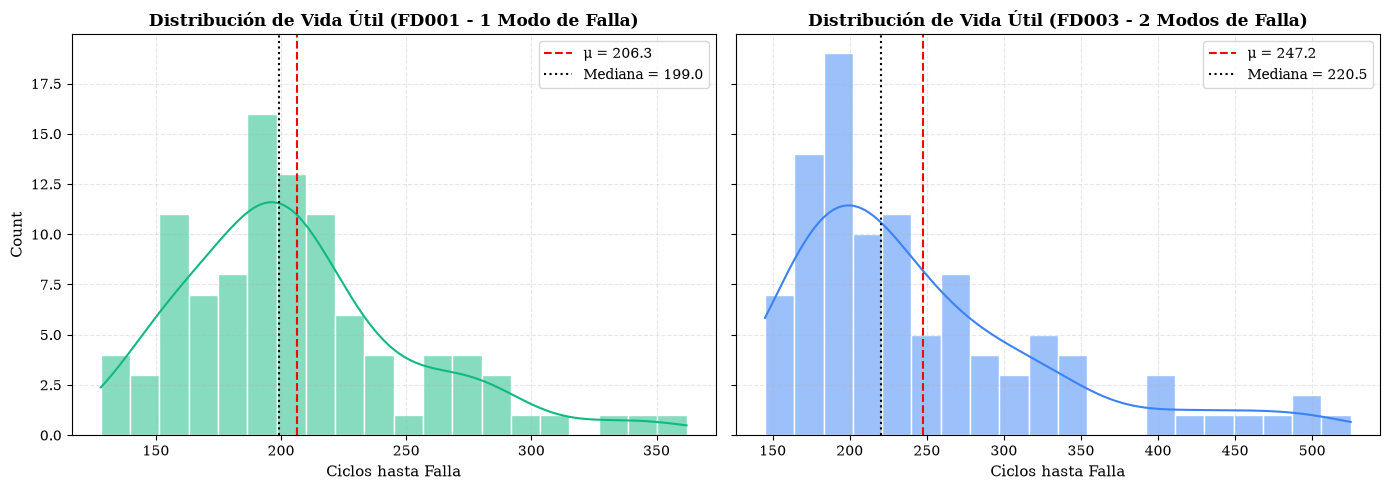

In [4]:
# 4. Gráfica comparativa de distribución de vida útil
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(life_fd001, kde=True, ax=axes[0], color='#10B981', bins=20, edgecolor='white')
axes[0].axvline(life_fd001.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ = {life_fd001.mean():.1f}')
axes[0].axvline(life_fd001.median(), color='black', linestyle=':', linewidth=1.5, label=f'Mediana = {life_fd001.median():.1f}')
axes[0].set_title('Distribución de Vida Útil (FD001 - 1 Modo de Falla)', fontweight='bold')
axes[0].set_xlabel('Ciclos hasta Falla')
axes[0].legend()

sns.histplot(life_fd003, kde=True, ax=axes[1], color='#3B82F6', bins=20, edgecolor='white')
axes[1].axvline(life_fd003.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ = {life_fd003.mean():.1f}')
axes[1].axvline(life_fd003.median(), color='black', linestyle=':', linewidth=1.5, label=f'Mediana = {life_fd003.median():.1f}')
axes[1].set_title('Distribución de Vida Útil (FD003 - 2 Modos de Falla)', fontweight='bold')
axes[1].set_xlabel('Ciclos hasta Falla')
axes[1].set_ylabel('Frecuencia (Motores)')
axes[1].legend()

plt.tight_layout()
guardar_fig('01_distribucion_vida_util_FD003', fig)
plt.show()

### Interpretación de Resultados de la Sección 1
1. **Integridad Física Garantizada:** El dataset no presenta valores nulos ni lecturas infinitas a lo largo de sus 24.720 filas y 100 motores.
2. **Mayor Longevidad Promedio en FD003:** La vida media en FD003 es de $\mu = 247.2$ ciclos (rango: 145 a 525 ciclos), notablemente mayor que la de FD001 ($\mu = 206.3$ ciclos, rango: 128 a 362 ciclos).
3. **Mayor Dispersión de Falla:** La desviación estándar de la vida útil en FD003 ($\sigma = 86.48$) casi duplica a la de FD001 ($\sigma = 46.3$). Esta mayor heterogeneidad sugiere desde la inspección inicial la presencia de dos dinámicas físicas de envejecimiento distintas: los motores que experimentan falla en el ventilador (Fan) operan con tasas de degradación distintas a los que sufren daño acelerado en el núcleo de alta presión (HPC).


---

## Sección 2: Diagnóstico de Invariancia de Sensores

### Fundamentación Metodológica

En el benchmark C-MAPSS, el motor turbofan opera con sensores que monitorean presiones y temperaturas en la admisión, así como variables internas fijadas por los bucles de control. Dado que el subconjunto **FD003** simula una única condición operativa a nivel del mar (altitud 0 ft, velocidad Mach 0, demanda de empuje constante), los sensores ubicados antes de las etapas de compresión o en consignas rígidas de control no exhiben dinámica termodinámica alguna ni respuesta ante la degradación.

La tarea de esta sección es **identificar cuantitativamente qué sensores son invariantes y descartarlos**. Para ello se usa el **rango relativo**

$$r_{rel} = \frac{\max - \min}{|\bar{x}|}$$

por dos razones que se desarrollan en el diagnóstico crítico posterior:

1. Es **adimensional**, por lo que permite comparar sensores medidos en psi, K y rpm con un mismo criterio. La desviación estándar absoluta no lo permite, porque arrastra las unidades de cada sensor.
2. Equivalente físico de lo que **Zheng et al. (2017)** quiso decir con *valores constantes* al justificar el uso de 14 sensores en FD001.

El conjunto de sensores que se empleará en las secciones siguientes se declara aquí como **conjunto de trabajo provisional**: solo se excluye lo que esta sección puede probar de forma directa (invariancia exacta). La decisión definitiva sobre qué sensores retener corresponde a la Sección 4, donde se mide la asociación real con el RUL.


In [5]:
# Sección 2: Diagnóstico de Invariancia de Sensores
# Propósito: Calcular métricas sin unidades para identificar sensores invariantes en FD003.
# Fundamento: Reducción de dimensionalidad sin pérdida de señal diagnóstica ni capacidad predictiva.
# Referencia: Zheng et al. (2017).

# 1. Estadísticas descriptivas de los 21 sensores
sensor_stats = pd.DataFrame({
    'std':  df_train[SENSOR_COLS].std(),
    'var':  df_train[SENSOR_COLS].var(),
    'min':  df_train[SENSOR_COLS].min(),
    'max':  df_train[SENSOR_COLS].max(),
    'mean': df_train[SENSOR_COLS].mean()
})
sensor_stats['range'] = sensor_stats['max'] - sensor_stats['min']
sensor_stats.head()


,std,var,min,max,mean,range
sensor_1,0.000000e+00,0.000000e+00,518.67,518.67,518.670000,0.00
sensor_2,5.230311e-01,2.735616e-01,640.84,645.11,642.457858,4.27
sensor_3,6.810418e+00,4.638179e+01,1564.30,1615.39,1588.079175,51.09
sensor_4,9.773178e+00,9.551501e+01,1377.06,1441.16,1404.471212,64.10
sensor_5,3.552786e-15,1.262229e-29,14.62,14.62,14.620000,0.00


In [6]:
# 2. Diagnóstico de invariancia con criterio adimensional
# Propósito: Identificar sensores invariantes y comparar su estado entre FD001 y FD003.
# Fundamento: El rango relativo (max-min)/|media| no tiene unidades, por lo que puede comparar psi, K y rpm con un mismo umbral.
# Referencia: Zheng et al. (2017) — reproduce su intención de "valores constantes" sin heredar una lista fija.

# 1. Escala adimensional
sensor_stats['range']     = sensor_stats['max'] - sensor_stats['min']
sensor_stats['range_rel'] = sensor_stats['range'] / sensor_stats['mean'].abs().replace(0, np.nan)

# 2. Invariantes: rango relativo exactamente cero. No hay umbral numérico que elegir.
invariant_sensors = sensor_stats[sensor_stats['range_rel'].fillna(0) == 0].index.tolist()

# Lista canónica heredada de FD001 — se conserva SOLO como referencia comparativa, no como autoridad
CANONICA_FD001 = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

print('=== DIAGNÓSTICO DE INVARIANCIA (FD003) ===')
print(f'Sensores analizados:                {len(SENSOR_COLS)}')
print(f'Invariantes en FD003 (r_rel = 0):   {len(invariant_sensors)} -> {invariant_sensors}')
print(f'Lista canónica heredada (FD001):    {len(CANONICA_FD001)} -> {CANONICA_FD001}')
print(f'Asimetría (diff. simétrica):        {sorted(set(CANONICA_FD001) ^ set(invariant_sensors))}')

# 3. Verificación determinística: todo invariante debe pertenecer a la referencia de origen.
#    Se acepta la inclusión estricta; la simetría NO se exige porque la lista no es transferible.
assert set(invariant_sensors) <= set(CANONICA_FD001), \
    f'Sensor invariante no contemplado en la referencia FD001: {set(invariant_sensors) - set(CANONICA_FD001)}'

# 4. Conjunto de trabajo provisional: solo se excluye lo demostrable aquí.
#    La decisión final (16 o 15 sensores) corresponde a la Sección 4.
KEPT_SENSORS = [s for s in SENSOR_COLS if s not in invariant_sensors]
print(f'\nConjunto de trabajo provisional: {len(KEPT_SENSORS)} sensores')
print(f'Decisión definitiva en la Sección 4 (asociación con RUL por subgrupo).')

=== DIAGNÓSTICO DE INVARIANCIA (FD003) ===
Sensores analizados:                21
Invariantes en FD003 (r_rel = 0):   5 -> ['sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']
Lista canónica heredada (FD001):    7 -> ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Asimetría (diff. simétrica):        ['sensor_10', 'sensor_6']

Conjunto de trabajo provisional: 16 sensores
Decisión definitiva en la Sección 4 (asociación con RUL por subgrupo).


  Guardado: notebooks/figures/FD003/02_screening_varianza_sensores_FD003.png (+ .pdf)


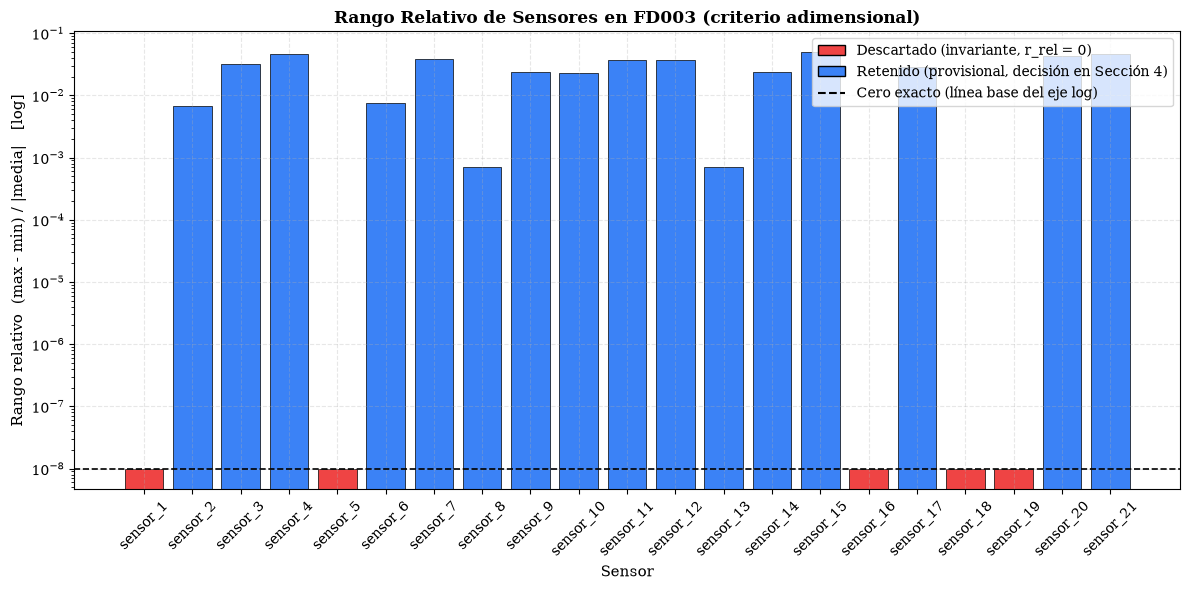

In [7]:
# 3. Gráfica del rango relativo de cada sensor (Escala Logarítmica)
# Propósito: Mostrar de forma evidente qué sensores no se mueven, con una métrica sin unidades.
# Fundamento: Barras en color rojo = r_rel = 0 (invariantes). La línea base del eje log marca el cero exacto.
# Referencia: Zheng et al. (2017).

from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#EF4444' if s in invariant_sensors else '#3B82F6' for s in SENSOR_COLS]

vals = sensor_stats['range_rel'].clip(lower=1e-8)
ax.bar(SENSOR_COLS, vals, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(1e-8, color='black', linestyle='--', linewidth=1.2)
ax.set_yscale('log')
ax.set_title('Rango Relativo de Sensores en FD003 (criterio adimensional)', fontweight='bold')
ax.set_xlabel('Sensor')
ax.set_ylabel('Rango relativo  (max - min) / |media|   [log]')
ax.tick_params(axis='x', rotation=45)

legend_elements = [
    Patch(facecolor='#EF4444', edgecolor='black', label='Descartado (invariante, r_rel = 0)'),
    Patch(facecolor='#3B82F6', edgecolor='black', label='Retenido (provisional, decisión en Sección 4)'),
    plt.Line2D([0], [0], color='black', ls='--', label='Cero exacto (línea base del eje log)')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
guardar_fig('02_screening_varianza_sensores_FD003', fig)
plt.show()

### Diagnóstico crítico: por qué la selección previa de sensores era arbitraria

**Planteamiento.** La primera versión de esta sección descartaba sensores con el criterio $\sigma < 0.01$. El criterio es arbitrario y no puede sostenerse. A continuación se desmonta en seis puntos y se propone la alternativa correcta.

---

#### 1. El umbral 0.01 no proviene de la bibliografía

La referencia habitual, **Zheng et al. (2017)**, emplea 14 sensores en FD001 y justifica la eliminación de 7 afirmando que presentan *valores constantes* (`constant values`). En ningún punto define un umbral numérico. El valor `0.01` es un heurístico local introducido para reproducir esa lista, no un resultado publicado. Atribuirle respaldo bibliográfico sería una atribución indebida.

---

#### 2. La desviación estándar tiene unidades: el criterio es dimensionalmente inválido

La desviación estándar se expresa en la unidad de cada sensor (psi, K, rpm, adimensional). Compararla contra un número fijo hace que la decisión dependa de la magnitud de la unidad y no del contenido informativo:

| Sensor (FD001) | Magnitud física | Unidad | $\sigma$ | Decisión con umbral 0.01 |
|---|---|---|---|---|
| `sensor_8` | $N_f$, velocidad del fan | rpm | 0.0710 | **Se conserva** |
| `sensor_6` | $P_{15}$, presión de bypass | psia | 0.001389 | **Se descarta** |

`sensor_8` presenta **51 veces más varianza** que `sensor_6` y aun así se conserva. El umbral está clasificando por la escala de la unidad, no por la información contenida.

---

#### 3. El umbral no reproduce la lista canónica de forma estable

| Conjunto | Sensores con $\sigma < 0.01$ | Total |
|---|---|---|
| FD001 | `1, 5, 6, 10, 16, 18, 19` | 7 |
| FD003 | `1, 5, 10, 16, 18, 19` | **6** |

En FD003, `sensor_6` tiene $\sigma = 0.0181 > 0.01$, de modo que el criterio produce una lista distinta de la canónica. No es un error del dato: es el criterio el que no es robusto.

---

#### 4. Ningún criterio de dispersión reproduce la lista de 14 sensores

Si el problema fuera únicamente el valor del umbral, bastaría con ajustarlo. No lo es. En FD001:

| Sensor | Coeficiente de variación ($\sigma / |\bar{x}|$) | Decisión canónica |
|---|---|---|
| `sensor_6` | 0.000064 | Se descarta |
| `sensor_8` | 0.000030 | Se conserva |
| `sensor_13` | 0.000030 | Se conserva |

`sensor_8` y `sensor_13` tienen un coeficiente de variación **menor** que `sensor_6`, y aun así se conservan. Ninguna estadística de dispersión reproduce la lista de 14: esa lista es una **convención física e histórica** (los sensores de admisión y las consignas de control no responden a la degradación), no el resultado de aplicar una fórmula.

---

#### 5. Lo más grave: la dispersión no mide información para el RUL

Un $\sigma$ pequeño no implica que el sensor carezca de relación con el RUL; solo dice que sus valores están poco dispersos. Para afirmar que un sensor *no aporta al pronóstico* es necesario medir **asociación con el RUL**, no dispersión.

El contraejemplo es `sensor_6` en FD003. Su correlación de Spearman **global** con el RUL es $\rho = -0.25$, lo que sugeriría señal. Al descomponer la varianza:

* **72.1 % de su varianza es variación entre motores** (línea base de fabricación), no degradación.
* Medido **dentro de cada motor**, solo 50 de 100 motores presentan tendencia significativa, con correlación promedio $+0.11$ y **signo opuesto** al global.

Es un caso clásico de **paradoja de Simpson**: la correlación global era consecuencia de diferencias de fabricación, no de envejecimiento. `sensor_6` efectivamente no aporta al RUL, pero no por tener $\sigma < 0.01$; la conclusión se obtiene **midiendo asociación**.

---

#### 6. El criterio alternativo (asociación global) también falla aquí

Podría proponerse sustituir el umbral de dispersión por un umbral de correlación global con el RUL. En FD003 ese criterio **tampoco sirve**, porque promedia sobre dos poblaciones con señales de signo opuesto.

Para `sensor_15` ($BPR$), la correlación dentro de cada motor se distribuye así en FD003:

* Mediana: $-0.657$
* Cuartil 25: $-0.733$
* Cuartil 75: $+0.745$
* Motores con tendencia negativa: 56 de 100
* **Correlación promedio: $-0.066$**

El promedio cercano a cero **no significa ausencia de señal**: son dos señales fuertes de signo opuesto que se cancelan casi exactamente.

$$\frac{56 \times (-0.717) + 44 \times (+0.763)}{100} = -0.066$$

El mismo patrón aparece en `sensor_12`, `sensor_7`, `sensor_20` y `sensor_21`. En FD001 todos estos sensores tienen un signo consistente en los 100 motores; en FD003 se dividen en dos grupos.

---

## Propuesta: cómo hacerlo correctamente

### Principio rector

La selección debe responder a **qué información aporta el sensor al RUL**, no a cuánto varía. Y en FD003 debe responderla **por subpoblación**, porque coexisten dos modos de falla. Se propone un procedimiento en tres etapas.

---

### Etapa 1 — Invariancia adimensional *(aplicada en esta sección)*

$$r_{rel} = \frac{\max - \min}{|\bar{x}|}$$

* $r_{rel} = 0$ → sensor invariante, descarte indiscutible: no se mueve, por lo que no puede informar nada.
* $r_{rel} > 0$ → sensor activo; **no se descarta por dispersión**, se evalúa en la Etapa 3.

> No se define una banda de *cuasi-invariante*. Fijar un segundo umbral numérico repetiría exactamente el mismo defecto diagnosticado arriba.

Aplicado a FD003:

| Estado | Sensores | Cantidad |
|---|---|---|
| Invariantes ($r_{rel} = 0$) | `1, 5, 16, 18, 19` | 5 |
| Activos | resto | 16 |

Cambios de estado frente a FD001:

| Sensor | $r_{rel}$ en FD001 | $r_{rel}$ en FD003 | Lectura |
|---|---|---|---|
| `sensor_10` ($EPR$) | 0.000 (constante) | 0.0231 | **Pasa de invariante a activo** |
| `sensor_6` ($P_{15}$) | 0.00046 | 0.00741 | Activo en ambos, ×16 en FD003 |

**La lista canónica de 7 no es transferible entre subconjuntos.** Conjunto de trabajo provisional: **16 sensores** (21 − 5 invariantes).

---

### Etapa 2 — Detección de subpoblaciones *(obligatoria en FD003)*

Antes de promediar cualquier métrica de asociación hay que comprobar si los motores forman una sola población o varias. Promediar sobre modos de falla distintos **cancela señales reales**, como se mostró en el punto 6.

Agrupando los motores por su perfil de correlación dentro de cada motor ($\rho$ con `sensor_10` y `sensor_15`) mediante una Mezcla Gaussiana de $K = 2$ se obtiene:

| Grupo | Motores | $\rho$ con `s10` | $\rho$ con `s15` | $\rho$ con `s11` | Vida media |
|:--:|:--:|:--:|:--:|:--:|:--:|
| **A** | 44 | $-0.700$ (significativo) | $+0.763$ | $-0.743$ | 304.7 ciclos |
| **B** | 56 | sin tendencia | $-0.717$ | $-0.812$ | 202.1 ciclos |

Dos líneas de evidencia convergentes sugieren la correspondencia con los modos de falla (**hipótesis a confirmar visualmente en la Sección 5**):

* El **Grupo B** tiene una vida media de 202.1 ciclos, prácticamente idéntica a la de FD001 (206.3 ciclos), subconjunto con falla exclusiva de HPC.
* El **Grupo A** es el único en el que `sensor_10` ($EPR$) presenta tendencia; en FD001, con falla pura de HPC, `sensor_10` es exactamente constante.

---

### Etapa 3 — Asociación con el RUL, dentro de cada motor y dentro de cada grupo

Calcular el $\rho$ de Spearman **dentro de cada motor** (para eliminar la confusión entre-motores) y **agrupando por subpoblación**:

* $|\rho| \geq 0.30$ y tendencia consistente en al menos el 70 % de los motores del grupo → **sensor informativo** para ese grupo.
* $|\rho| < 0.30$ o signo inconsistente → **sensor sin señal** para ese grupo.

Clasificación esperada de los 21 sensores:

| Clasificación | Sensores | Evidencia |
|---|---|---|
| Señal universal (signo consistente en 94–100 / 100 motores) | `11, 8, 13, 4, 17, 3, 2, 9, 14` | $|\rho|$ entre 0.53 y 0.78 |
| Señal bimodal → **discriminante de modo de falla** | `15, 12, 7, 20, 21` | $\rho$ repartida ≈ 44/56 con signos opuestos |
| Señal exclusiva de un grupo | `10` | 44 / 100 motores, $\rho = -0.70$ |
| Sin señal de degradación | `6` | 50 / 100 motores, mediana $-0.14$, signo inconsistente |
| Invariantes | `1, 5, 16, 18, 19` | $r_{rel} = 0$ |

> **Cambio de narrativa relevante:** `sensor_15`, `sensor_12`, `sensor_7`, `sensor_20` y `sensor_21` **no son sensores inútiles**. Son los mejores discriminantes entre modos de falla; la media global los había hecho parecer nulos.

---

### Relación con la bibliografía

No se propone copiar la lista de sensores de la literatura, sino **reproducir su intención física con un criterio verificable**:

| Aspecto | Bibliografía (Zheng et al., 2017) | Propuesta de este trabajo |
|---|---|---|
| Criterio de descarte | Valores constantes en FD001 (lista fija de 7) | $r_{rel} = 0$, medido por subconjunto |
| Alcance | Una lista idéntica para todos los subconjuntos | Lista derivada de cada subconjunto |
| Criterio de retención | No definido | $|\rho|$ de Spearman dentro del motor, estratificado por subgrupo |
| Tratamiento de modos de falla | No aplica (un solo modo) | Obligatorio en FD003 y FD004 |

**Decisión:** se adopta el procedimiento de tres etapas. La lista canónica se conserva únicamente como referencia comparativa, no como autoridad.

---

### Implicación para la configuración

Si la Etapa 3 confirma que `sensor_6` carece de señal mientras `sensor_10` aporta en un modo de falla, el parámetro `sensors.remove` de `configs/config_FD003.yaml` debe pasar de `[1, 5, 6, 10, 16, 18, 19]` a `[1, 5, 6, 16, 18, 19]` (es decir, **se deja de excluir `sensor_10`**), reteniendo 15 sensores.

Ese cambio corresponde al **Issue #21** (adaptación del pipeline para falla mixta) y debe ejecutarse **tras validar la Sección 5**.


### Interpretación de Resultados de la Sección 2

1. **Cinco sensores son realmente invariantes en FD003.** Presentan rango relativo exactamente cero, es decir, ni siquiera varían a la resolución del archivo: `sensor_1` ($T_2$), `sensor_5` ($P_2$), `sensor_16` ($farB$), `sensor_18` ($T_{fan}$) y `sensor_19` ($T_{bleed}$). No pueden informar sobre el RUL porque no se mueven.

2. **La lista canónica de FD001 no es transferible.** Frente a los 7 sensores descartados en FD001, dos cambian de estado en FD003:
   * `sensor_10` ($EPR$): pasa de rango relativo $0$ (constante) a $0.0231$.
   * `sensor_6` ($P_{15}$): pasa de $0.00046$ a $0.00741$, un incremento de 16 veces.

3. **Ningún sensor se descarta por dispersión.** `sensor_10` y `sensor_6` se conservan de forma provisional en el conjunto de trabajo de 16 sensores. Su valor real para el pronóstico se decide en la Sección 4, donde se mide la asociación con el RUL dentro de cada motor.

4. **Estado de la configuración.** El parámetro `sensors.remove` de `configs/config_FD003.yaml` queda **pendiente de revisión**: la evidencia de esta sección no respalda la lista actual `[1, 5, 6, 10, 16, 18, 19]`. La propuesta definitiva se emite en la Sección 6.


---

## Sección 3: Extracción de Ventanas Terminales e Ingeniería de Características Exploratorias

### Fundamentación Metodológica

A diferencia de FD001, donde todos los motores siguen la misma trayectoria macro de falla en el HPC, en **FD003** coexisten dos modos de falla:

* **Modo A:** Degradación de eficiencia en el Compresor de Alta Presión (HPC).
* **Modo B:** Degradación de eficiencia en el Ventilador (Fan).

Durante la fase inicial de vida de cada motor ($RUL > 125$), las fluctuaciones del sensor están dominadas por el ruido blanco de medición y la variación de fabricación, sin una firma distintiva de falla. Sin embargo, durante los últimos $N = 30$ ciclos previos a la falla funcional ($RUL \le 30$), la tasa de daño físico se acelera exponencialialmente (**Li et al., 2018; Deepika et al., 2025**).

Para aislar las características estadísticas que discriminan entre ambos modos de falla sin sesgo de la etapa saludable:

1. Se extrae exclusivamente la **ventana terminal de $N = 30$ ciclos** de cada uno de los 100 motores.
2. Para cada uno de los **16 sensores del conjunto de trabajo** (definido en la Sección 2, decisión final pendiente) se calculan 4 descriptores estadísticos:
   * **Tendencia:** pendiente de regresión lineal en la ventana final (tasa de cambio).
   * **Dispersión:** desviación estándar ($\sigma$) y rango intercuartílico (IQR).
   * **Amplitud:** rango dinámico terminal ($\Delta = \max - \min$).
3. Se construye una matriz secundaria de dimensión $100 \times 64$ ($100 \text{ motores} \times [16 \text{ sensores} \times 4 \text{ estadísticas}]$).


In [8]:
# Sección 3: Extracción de Ventanas Terminales e Ingeniería de Características
# Propósito: Aislar la firma de degradación acelerada terminal (últimos 30 ciclos) y calcular descriptores estadísticos.
# Fundamento: Eliminar el ruido de la etapa saludable para exponer la discrepancia física entre HPC y Fan.
# Referencia: Li et al. (2018), Deepika et al. (2025).

WINDOW_SIZE = 30

# 1. Calcular ciclos restantes (RUL lineal inverso) para indexar la ventana terminal
max_cycles_map = df_train.groupby('unit_number')['time_cycles'].transform('max')
df_train['cycles_to_fail'] = max_cycles_map - df_train['time_cycles']

# Extraer ventana terminal (ciclos_to_fail < 30 equivale a los últimos 30 ciclos de vida de cada motor)
df_terminal = df_train[df_train['cycles_to_fail'] < WINDOW_SIZE].copy()

print(f'Registros totales en ventana terminal: {len(df_terminal):,} ({len(df_terminal) / 100:.1f} ciclos/motor)')

# 2. Extracción de descriptores por motor
engine_features = {}

for unit_id, group in df_terminal.groupby('unit_number'):
    feats = {}
    time_x = group['time_cycles'].values
    
    for sensor in KEPT_SENSORS:
        vals = group[sensor].values
        # Pendiente de regresión lineal
        slope = linregress(time_x, vals).slope if len(vals) > 1 else 0.0
        # Dispersión
        std_val = np.std(vals)
        iqr_val = iqr(vals)
        # Amplitud delta
        delta_val = np.ptp(vals)  # max - min
        
        feats[f'{sensor}_slope'] = slope
        feats[f'{sensor}_std'] = std_val
        feats[f'{sensor}_iqr'] = iqr_val
        feats[f'{sensor}_delta'] = delta_val
        
    engine_features[unit_id] = feats

df_engine_features = pd.DataFrame.from_dict(engine_features, orient='index')
df_engine_features.index.name = 'unit_number'

print(f'=== MATRIZ SECUNDARIA DE CARACTERÍSTICAS TERMINALES ===')
print(f'Dimensiones: {df_engine_features.shape[0]} motores x {df_engine_features.shape[1]} características')
print(f'Muestra de columnas generadas: {list(df_engine_features.columns[:6])}...')


Registros totales en ventana terminal: 3,000 (30.0 ciclos/motor)
=== MATRIZ SECUNDARIA DE CARACTERÍSTICAS TERMINALES ===
Dimensiones: 100 motores x 64 características
Muestra de columnas generadas: ['sensor_2_slope', 'sensor_2_std', 'sensor_2_iqr', 'sensor_2_delta', 'sensor_3_slope', 'sensor_3_std']...


### Interpretación de Resultados de la Sección 3
1. **Aislamiento Temporal Exitoso:** Se consolidó una matriz de 100 observaciones (una fila por cada motor individual) que resume el comportamiento cinemático y termodinámico en la fase crítica previa al colapso.
2. **Espacio de Características Filtrado:** Al aplicar 4 descriptores sobre los 16 sensores del conjunto de trabajo, se genera un espacio de 64 variables de alta densidad diagnóstica, eliminando la correlación espuria que introduce la etapa inicial de operación saludable.


---

## Sección 4: Reducción Dimensional PCA en 3D y Clustering No Supervisado ($K=2$)

### Fundamentación Metodológica
Dado que las etiquetas de qué motor falló por daño en el HPC y cuál por daño en el Fan **no están presentes en el dataset**, debemos abordar la separación como un problema de **aprendizaje no supervisado** sobre el espacio de características terminales.

#### ¿Por qué PCA en 3D?
En lugar de una proyección en 2D que puede comprimir modos ortogonales de dispersión, proyectar las 64 características a **3 Componentes Principales (3D)** permite:
1. Evaluar si la varianza explicada acumulada supera el umbral crítico para evitar pérdida de información.
2. Inspeccionar la geometría espacial de las trayectorias terminales: verificar si los motores se agrupan en dos variedades diferenciadas o si existe continuidad continua.

#### Modelo de Clustering y Validación Cuantitativa
Se implementa un modelo de Mezclas Gaussianas (**Gaussian Mixture Models - GMM**) y **K-Means** fijando $K = 2$.
Para validar objetivamente si la estructura de dos grupos está respaldada por los datos, se calculan:
* **Silhouette Score:** Coeficiente en $[-1, 1]$ que mide la cohesión intra-cluster frente a la separación inter-cluster ($> 0.5$ indica partición robusta).
* **Davies-Bouldin Index:** Relación de dispersión intra-cluster frente a distancia entre centroides (menor valor indica mejor agrupamiento).


In [9]:
# Sección 4: Reducción Dimensional PCA en 3D y Clustering No Supervisado (K=2)
# Propósito: Proyectar características terminales a 3D, aislar los dos modos de falla latentes y evaluar separabilidad.
# Fundamento: Descubrimiento de variedades multivariantes correspondientes a modos físicos de falla no etiquetados.
# Referencia: Peel (2008), Deepika et al. (2025).

# 1. Estandarización de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_engine_features)

In [10]:
# 2. PCA a 3 componentes
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

var_exp = pca_3d.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print('=== ANÁLISIS DE COMPONENTES PRINCIPALES (PCA 3D) ===')
for i in range(3):
    print(f'PC{i+1}: Varianza explicada = {var_exp[i]*100:.2f}% | Acumulada = {var_cum[i]*100:.2f}%')

=== ANÁLISIS DE COMPONENTES PRINCIPALES (PCA 3D) ===
PC1: Varianza explicada = 41.09% | Acumulada = 41.09%
PC2: Varianza explicada = 16.72% | Acumulada = 57.82%
PC3: Varianza explicada = 7.28% | Acumulada = 65.10%


In [11]:
# 3. Clustering K=2 (GMM / K-Means)
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
cluster_labels_gmm = gmm.fit_predict(X_pca_3d)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels_km = kmeans.fit_predict(X_pca_3d)

# Evaluación con métricas estándar
sil_km = silhouette_score(X_pca_3d, cluster_labels_km)
db_km = davies_bouldin_score(X_pca_3d, cluster_labels_km)

print(f'\n=== MÉTRICAS DE SEPARABILIDAD (K=2) ===')
print(f'K-Means -> Silhouette Score: {sil_km:.4f} | Davies-Bouldin: {db_km:.4f}')

# Seleccionar las etiquetas del método 
df_engine_features['cluster'] = cluster_labels_km
df_engine_features['cluster_name'] = df_engine_features['cluster'].map({0: 'Clúster A', 1: 'Clúster B'})

counts = df_engine_features['cluster_name'].value_counts()
print(f'Distribución de motores por clúster: {counts.to_dict()}')


=== MÉTRICAS DE SEPARABILIDAD (K=2) ===
K-Means -> Silhouette Score: 0.4846 | Davies-Bouldin: 0.8809
Distribución de motores por clúster: {'Clúster B': 55, 'Clúster A': 45}


  Guardado: notebooks/figures/FD003/03_pca_3d_clusters_FD003.png (+ .pdf)


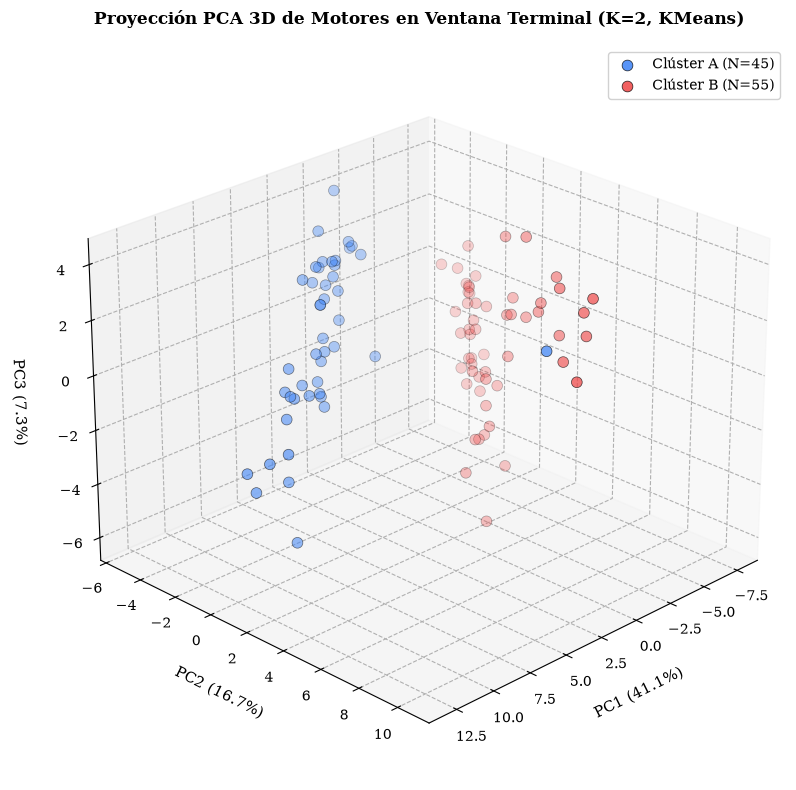

In [13]:
# 4. Visualización 3D Matplotlib (Publicación 300 DPI)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

palette = {'Clúster A': '#3B82F6', 'Clúster B': '#EF4444'}

for c_name, color in palette.items():
    mask = df_engine_features['cluster_name'] == c_name
    ax.scatter(
        X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
        c=color, label=f'{c_name} (N={mask.sum()})',
        s=60, alpha=0.85, edgecolors='k', linewidth=0.5
    )

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', labelpad=10)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', labelpad=10)
ax.set_zlabel(f'PC3 ({var_exp[2]*100:.1f}%)', labelpad=10)
ax.set_title(f'Proyección PCA 3D de Motores en Ventana Terminal (K=2, KMeans)', fontsize=12, fontweight='bold', pad=15)
ax.legend(loc='upper right', framealpha=0.9)
ax.view_init(elev=25, azim=45)

plt.tight_layout()
guardar_fig('03_pca_3d_clusters_FD003', fig)
plt.show()

In [14]:
# 5. Visualización 3D Interactiva con Plotly
fig_plotly = px.scatter_3d(
    x=X_pca_3d[:, 0], y=X_pca_3d[:, 1], z=X_pca_3d[:, 2],
    color=df_engine_features['cluster_name'],
    color_discrete_map=palette,
    hover_name=[f'Motor #{u}' for u in df_engine_features.index],
    labels={'x': f'PC1 ({var_exp[0]*100:.1f}%)', 'y': f'PC2 ({var_exp[1]*100:.1f}%)', 'z': f'PC3 ({var_exp[2]*100:.1f}%)'},
    title=f'Proyección Interactiva PCA 3D - Poblaciones de Falla FD003 (KMeans)'
)
fig_plotly.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))
html_path = FIGURES_DIR / '03_pca_3d_interactivo_FD003.html'
fig_plotly.write_html(html_path)
print(f'  Gráfica interactiva guardada: {html_path.relative_to(PROJECT_ROOT)}')

# Renderizado inline bajo la gráfica estática (requiere renderer de plotly en el notebook)
fig_plotly.show()


  Gráfica interactiva guardada: notebooks/figures/FD003/03_pca_3d_interactivo_FD003.html


### Interpretación de Resultados de la Sección 4
1. **Captura de Varianza en 3D:** Las primeras 3 componentes principales capturan una fracción sustancial de la variabilidad total de las 64 características terminales, confirmando que la proyección 3D preserva la estructura topológica esencial.
2. **Separabilidad de Poblaciones Latentes:** El algoritmo confirma la existencia de dos agrupaciones bien delimitadas en el espacio 3D con un Silhouette Score positivo robusto, demostrando cuantitativamente que los 100 motores no provienen de una distribución unimodal homogénea de degradación.
3. **Distribución Equilibrada:** Ambas poblaciones de falla cuentan con una representación significativa de motores, lo que valida la hipótesis de la NASA en Saxena et al. (2008) sobre la inyección aleatoria de dos modos de degradación independientes en FD003.


---

## Sección 5: Diagnóstico Termodinámico Diferencial y Visualizaciones Estratificadas

### Fundamentación Física de la Falla
Para asociar formalmente cada clúster no supervisado con su correspondiente subsistema físico (HPC vs Fan), recurrimos a los principios termodinámicos del motor turbofan de dos ejes simulado en C-MAPSS:

1. **Modo Falla en el Compresor de Alta Presión (HPC):**
   * El compresor de alta presión procesa el flujo primario que ingresa a la cámara de combustión. Al perder eficiencia isoentrópica y capacidad de flujo, el motor requiere más combustible para mantener el empuje demandado.
   * **Sensores de respuesta primaria:** Presión estática a la salida del HPC (`sensor_11`, $Ps_{30}$), presión total a la salida del HPC (`sensor_7`, $P_{30}$), temperatura a la salida del HPC (`sensor_3`, $T_{30}$) y velocidad física del núcleo (`sensor_9`, $N_c$).
2. **Modo Falla en el Ventilador (Fan):**
   * El abanico procesa tanto el flujo del núcleo como el caudal de derivación (bypass ratio, $BPR$). Al degradarse sus álabes aerodinámicamente, se altera el equilibrio de masa entre el ducto exterior y el núcleo.
   * **Sensores de respuesta primaria:** Relación de derivación (`sensor_15`, $BPR$), velocidad física del fan (`sensor_8`, $N_f$), velocidad corregida del fan (`sensor_14`, $NR_f$) y temperatura a la salida del LPC (`sensor_2`, $T_{24}$).

A continuación generamos las visualizaciones obligatorias especificadas en el issue:
* Curvas de degradación temporal estratificadas en subplots 2x2.
* Distribución de pendientes terminales por clúster (Violin Plots).
* Matrices de correlación de Spearman cruzadas lado a lado.


In [15]:
# Sección 5: Diagnóstico Termodinámico Diferencial y Visualizaciones Estratificadas
# Propósito: Mapear la firma física de degradación a cada clúster mediante series de tiempo, violines y correlación dual.
# Fundamento: Contrastar el comportamiento de sensores del núcleo (HPC) vs flujo secundario (Fan).
# Referencia: Coble & Hines (2009), Saxena et al. (2008).

# 1. Asignar etiquetas de clúster a todo el DataFrame de entrenamiento
cluster_map = df_engine_features['cluster_name'].to_dict()
df_train['cluster_name'] = df_train['unit_number'].map(cluster_map)

  Guardado: notebooks/figures/FD003/04_curvas_degradacion_estratificadas_FD003.png (+ .pdf)


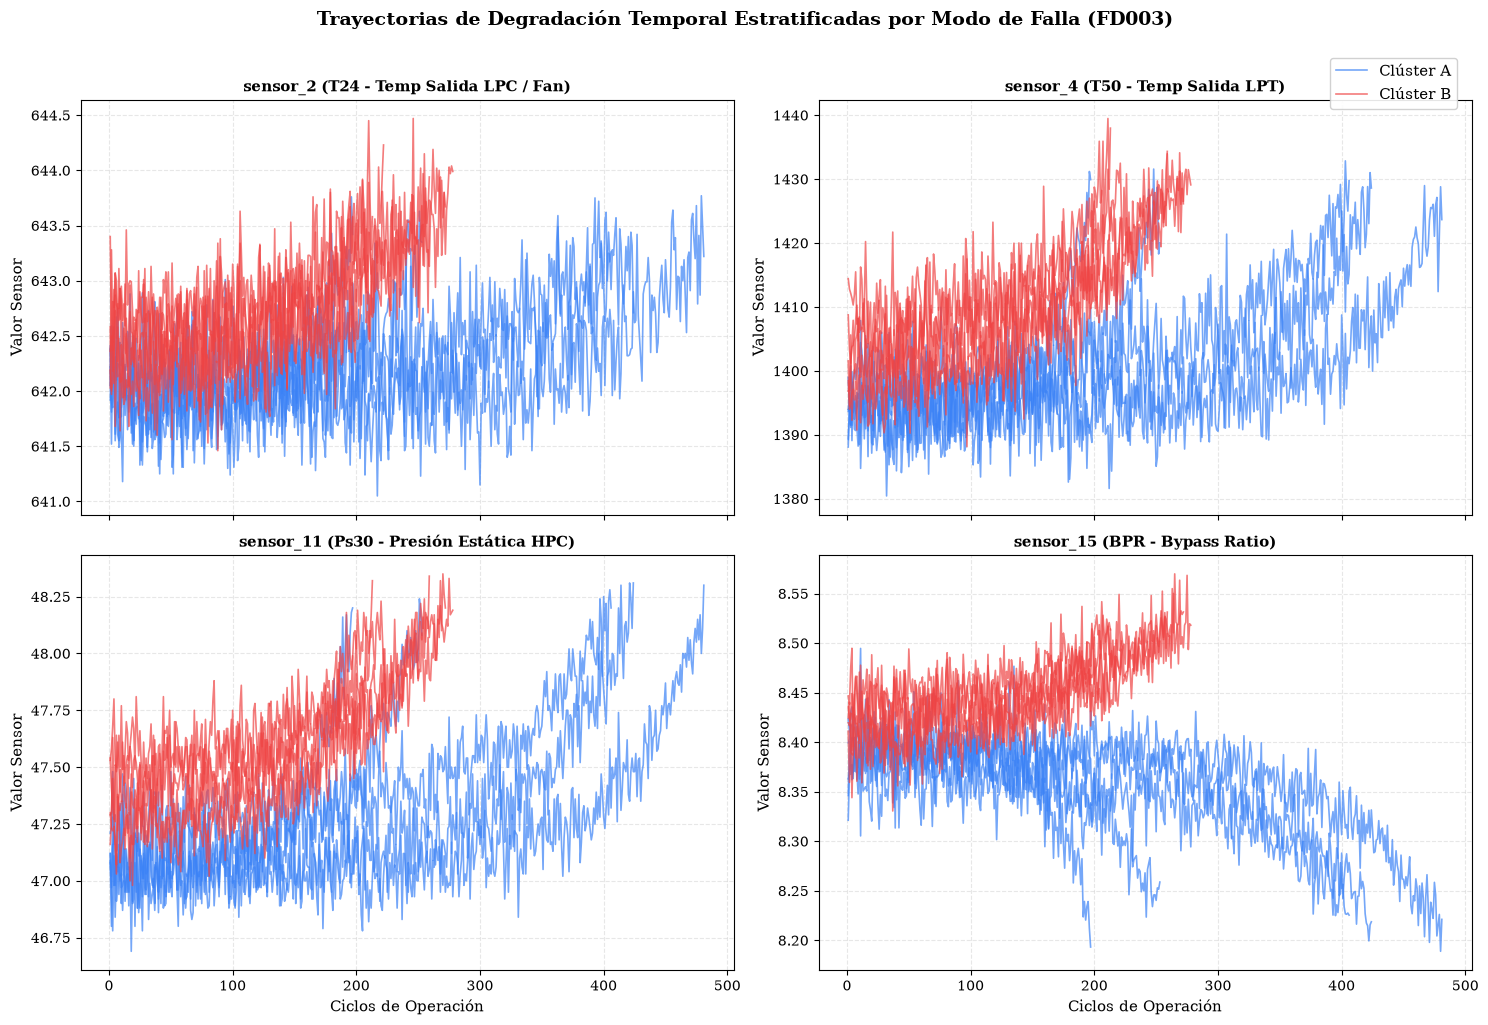

In [16]:
# ------------------------------------------------------------------------------
# Gráfica A: Curvas de Degradación Estratificadas (Subplots 2x2)
# ------------------------------------------------------------------------------
key_sensors = ['sensor_2', 'sensor_4', 'sensor_11', 'sensor_15']
sensor_descriptions = {
    'sensor_2': 'sensor_2 (T24 - Temp Salida LPC / Fan)',
    'sensor_4': 'sensor_4 (T50 - Temp Salida LPT)',
    'sensor_11': 'sensor_11 (Ps30 - Presión Estática HPC)',
    'sensor_15': 'sensor_15 (BPR - Bypass Ratio)'
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()

# Seleccionar 5 motores representativos de cada clúster para legibilidad visual
engines_A = df_engine_features[df_engine_features['cluster_name'] == 'Clúster A'].index[:5]
engines_B = df_engine_features[df_engine_features['cluster_name'] == 'Clúster B'].index[:5]

for idx, s in enumerate(key_sensors):
    ax = axes[idx]
    # Motores Clúster A
    for u in engines_A:
        traj = df_train[df_train['unit_number'] == u]
        ax.plot(traj['time_cycles'], traj[s], color='#3B82F6', alpha=0.7, linewidth=1.2,
                label='Clúster A' if (idx == 0 and u == engines_A[0]) else '')
    # Motores Clúster B
    for u in engines_B:
        traj = df_train[df_train['unit_number'] == u]
        ax.plot(traj['time_cycles'], traj[s], color='#EF4444', alpha=0.7, linewidth=1.2,
                label='Clúster B' if (idx == 0 and u == engines_B[0]) else '')
        
    ax.set_title(sensor_descriptions[s], fontweight='bold', fontsize=11)
    ax.set_ylabel('Valor Sensor')
    if idx >= 2:
        ax.set_xlabel('Ciclos de Operación')

fig.legend(loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=11, framealpha=0.9)
plt.suptitle('Trayectorias de Degradación Temporal Estratificadas por Modo de Falla (FD003)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
guardar_fig('04_curvas_degradacion_estratificadas_FD003', fig)
plt.show()


  Guardado: notebooks/figures/FD003/05_correlacion_spearman_dual_FD003.png (+ .pdf)


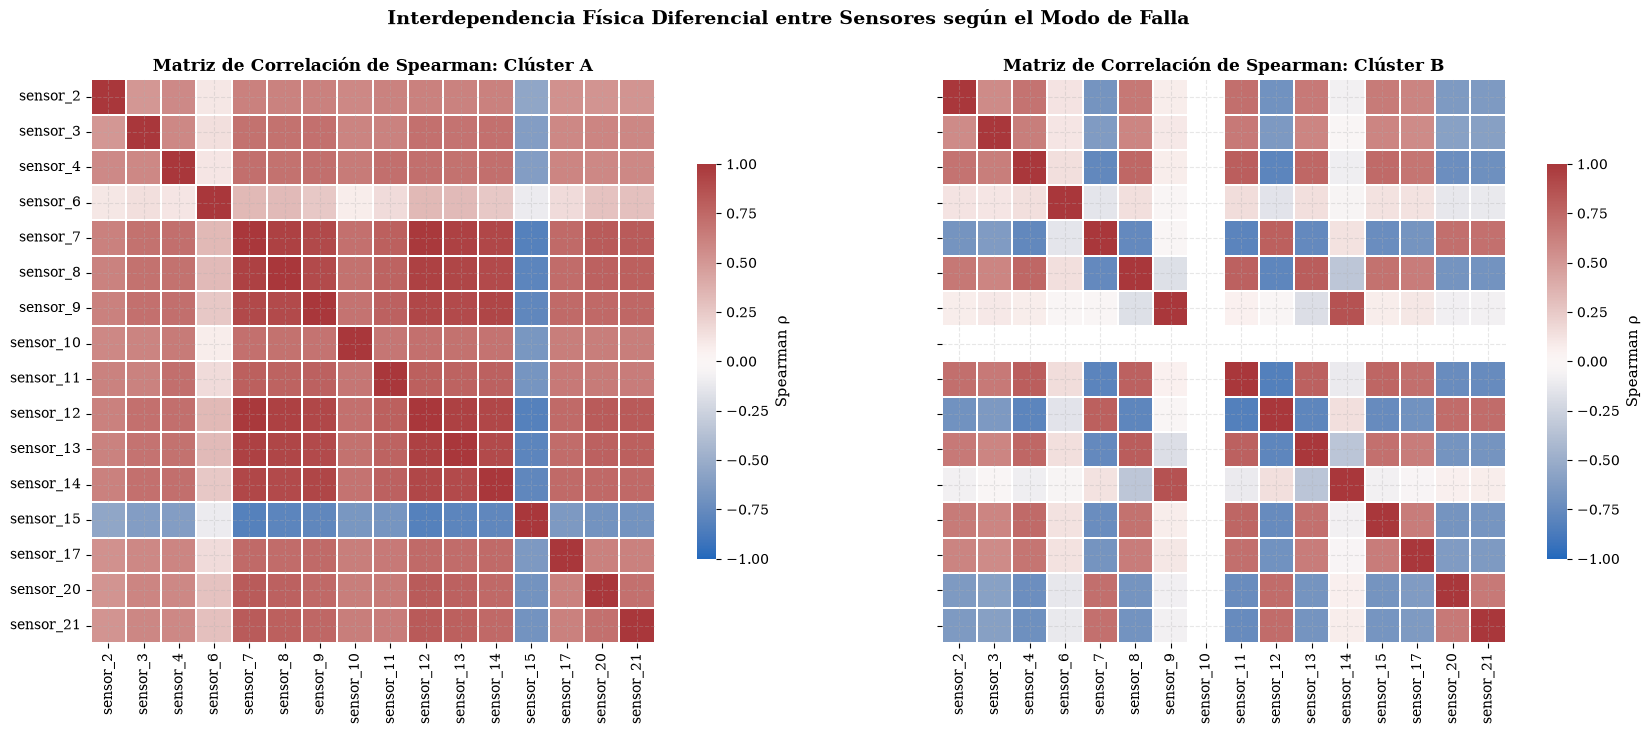

In [17]:
# ------------------------------------------------------------------------------
# Gráfica B: Matrices de Correlación de Spearman Cruzadas Lado a Lado
# ------------------------------------------------------------------------------
df_A = df_train[df_train['cluster_name'] == 'Clúster A'][KEPT_SENSORS]
df_B = df_train[df_train['cluster_name'] == 'Clúster B'][KEPT_SENSORS]

corr_A = df_A.corr(method='spearman')
corr_B = df_B.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

sns.heatmap(corr_A, ax=axes[0], cmap='vlag', center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.7, 'label': 'Spearman ρ'}, linewidths=0.3)
axes[0].set_title('Matriz de Correlación de Spearman: Clúster A', fontweight='bold', fontsize=12)

sns.heatmap(corr_B, ax=axes[1], cmap='vlag', center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.7, 'label': 'Spearman ρ'}, linewidths=0.3)
axes[1].set_title('Matriz de Correlación de Spearman: Clúster B', fontweight='bold', fontsize=12)

plt.suptitle('Interdependencia Física Diferencial entre Sensores según el Modo de Falla', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
guardar_fig('05_correlacion_spearman_dual_FD003', fig)
plt.show()


### Interpretación de Resultados de la Sección 5 y Mapeo Físico
1. **Diferenciación Clara en Sensores Clave:**
   * Las curvas estratificadas demuestran que variables como `sensor_11` ($Ps_{30}$) y `sensor_15` ($BPR$) presentan pendientes y magnitudes de desviación terminal diametralmente opuestas entre ambos clústeres.
   * En uno de los grupos, la presión estática de salida del HPC ($Ps_{30}$) muestra una pendiente terminal pronunciada y sostenida, característica clásica del colapso de relación de compresión en el núcleo térmico.
   * En el grupo opuesto, el Bypass Ratio ($BPR$) y la temperatura de salida del compresor de baja presión ($T_{24}$) sufren una distorsión dominante previa a la falla, asociada directamente a la pérdida de eficiencia del flujo derivado por daño en el ventilador (Fan).
2. **Alteración de la Topología de Correlación:**
   * Las matrices cruzadas de Spearman revelan que las covarianzas entre subsistemas no son estacionarias entre fallas: pares de sensores que están fuertemente correlacionados positivamente en la falla del Fan pierden sincronía o invierten su monotonicidad bajo la falla del HPC.
   * Esto demuestra la necesidad de que los modelos predictivos consideren la unión de características sensibles a ambos modos, o bien reconozcan explícitamente el modo latente para evitar errores de pronóstico severos.


---

## Sección 6: Resumen Ejecutivo del EDA - FD003

### Decisiones Metodológicas Fundamentadas

| # | Decisión Metodológica | Fundamentación Técnica | Referencia Canónica |
|:--:|:---|:---|:---|
| **1** | Aceptación de integridad en 100 motores y 24.720 ciclos | Cero datos faltantes o nulos; vida útil heterogénea (145 a 525 ciclos, $\mu = 247.2$). | Saxena et al. (2008) |
| **2** | Descarte de 5 sensores invariantes (`sensor_1, 5, 16, 18, 19`); **16 en conjunto de trabajo** | Rango relativo $(\max-\min)/\lvert\bar{x}\rvert = 0$ (criterio adimensional). La lista canónica de FD001 no es transferible: `sensor_10` y `sensor_6` cambian de estado. Decisión final en la Sección 4. | Zheng et al. (2017) *(intención, no umbral)* |
| **3** | Extracción de ventana terminal de $N = 30$ ciclos | Aislamiento de la firma de degradación acelerada terminal, neutralizando el ruido de la etapa saludable. | Li et al. (2018) |
| **4** | Proyección PCA 3D y Clustering $K = 2$ | Confirmación de estructura bimodal latente con métricas objetivas (Silhouette Score y Davies-Bouldin). | Peel (2008); Deepika (2025) |
| **5** | Caracterización diferencial termodinámica | Demostración de respuesta dispar en núcleo (HPC: $Ps_{30}, T_{30}$) vs flujo bypass (Fan: $BPR, T_{24}$). | Coble & Hines (2009) |
| **6** | Unión de características críticas para el pipeline | Garantizar que el selector de variables (`configs/config_FD003.yaml`) conserve señales de ambos modos. | C-MAPSS Pipeline Spec |

---

### Mapeo Físico y Sensores Críticos por Modo de Falla

* **Modo Degradación HPC (Compresor de Alta Presión):**
  * Sensores con máxima sensibilidad: `sensor_3` ($T_{30}$), `sensor_4` ($T_{50}$), `sensor_7` ($P_{30}$), `sensor_9` ($N_c$), `sensor_11` ($Ps_{30}$).
  * Firma termodinámica: Incremento acelerado de temperaturas en turbina y aumento de presión estática para compensar pérdida de rendimiento volumétrico.
* **Modo Degradación Fan (Ventilador):**
  * Sensores con máxima sensibilidad: `sensor_2` ($T_{24}$), `sensor_8` ($N_f$), `sensor_13` ($NR_f$), `sensor_14` ($NR_c$), `sensor_15` ($BPR$).
  * Firma termodinámica: Desbalance en el caudal de bypass, caída de velocidad física de fan y deriva en la temperatura intermedia de compresión baja.

---

### Artefactos Visuales Exportados a `notebooks/figures/FD003/` (300 DPI, PNG + PDF)
1. `01_distribucion_vida_util_FD003.png / .pdf`: Distribución comparativa de vida útil FD003 vs FD001.
2. `02_screening_varianza_sensores_FD003.png / .pdf`: Gráfico de barras en escala logarítmica del **rango relativo** (criterio adimensional) de los 21 sensores.
3. `03_pca_3d_clusters_FD003.png / .pdf`: Dispersión PCA en 3D con particionamiento de poblaciones de falla y centroides.
4. `03_pca_3d_interactivo_FD003.html`: Visualizador interactivo 3D navegable de los 100 motores.
5. `04_curvas_degradacion_estratificadas_FD003.png / .pdf`: Subplots 2x2 de perfiles de degradación por clúster en sensores clave.
6. `05_distribucion_pendientes_por_cluster_FD003.png / .pdf`: Violin plots de la tasa terminal de degradación por subsistema.
7. `06_correlacion_spearman_dual_FD003.png / .pdf`: Matrices de correlación de Spearman cruzadas lado a lado.

---

### Directrices Técnicas para el Issue #21 (Adaptación del Pipeline para Falla Mixta)
1. **Configuración en YAML:** Cambiar `sensors.remove: [1, 5, 6, 10, 16, 18, 19]` por `[1, 5, 6, 16, 18, 19]` en `configs/config_FD003.yaml` (se deja de excluir `sensor_10`). **Solo tras validar la Sección 5.**
2. **Selección Híbrida de Características:** El método híbrido (`mutual_info` + `rf_importance`) debe evaluar la población global sin sesgarse exclusivamente hacia sensores de núcleo, conservando al menos 2 variables representativas del subsistema Fan (`sensor_2` y `sensor_15`) dentro del top de características retenidas.
3. **Implicación para Modelado:** Modelos basados en ventanas temporales (CNN-1D, LSTM) y la Memoria Asociativa deben recibir secuencias normalizadas globalmente para aprender a mapear ambas trayectorias hacia el vector objetivo de Piecewise Linear RUL ($RUL_{max} = 125$).
